# CISC455/851: Validation and Performance Analysis
---
## 1. Environment and Class Definitions
To load the serialized model (`best_timing.pkl`), we must initialize the exact class structures that were used during the training phase. This ensures the `pickle` library knows how to map the saved byte data back into Python objects.

In [13]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pygame
import random
import sys

# --- Environment Configuration ---
GRID_SIZE = 4
ROAD_LEN = 1000
SPAWN_RATE = 0.12
# Note: For perfect replay accuracy, these should match the exact intersection coordinates generated during your training run.
INTERSECTIONS = [160, 380, 620, 860] 

class Vehicle:
    def __init__(self, vid, vtype, axis, direction, channel):
        self.id = vid
        self.length = 1 if vtype == 'car' else 3
        self.axis = axis           
        self.direction = direction 
        self.pos = 0 if direction == 1 else ROAD_LEN
        self.channel = channel
        self.speed = 10            
        self.accel = 2 if vtype == 'car' else 1
        self.idling_time = 0
        self.travel_time = 0
        self.finished = False

    def step(self, dist_to_front):
        if self.finished: return
        if dist_to_front <= self.speed + 2:
            self.speed = max(0, dist_to_front - 2)
            if self.speed == 0: self.idling_time += 1
        else:
            self.speed = min(10, self.speed + self.accel)
        
        self.pos += (self.speed * self.direction)
        self.travel_time += 1
        if (self.direction == 1 and self.pos >= ROAD_LEN) or (self.direction == -1 and self.pos <= 0):
            self.finished = True

class TimingBlock:
    def __init__(self, g_ns, g_ew):
        self.seq = ([0]*g_ns) + [1,1,1,1,1,1,4,4,4] + ([2]*g_ew) + [3,3,3,3,3,3,4,4,4]

def flatten_genes(blocks):
    full_seq = []
    for b in blocks: full_seq.extend(b.seq)
    if len(full_seq) < 3600:
        full_seq.extend([4] * (3600 - len(full_seq)))
    return np.array(full_seq[:3600])

print("Classes and environment initialized successfully.")

Classes and environment initialized successfully.


## 2. Evolved Genotype Visualization
This section unpacks the evolved chromosome and plots the phase transitions. This chart is ideal for your presentation slides to visually demonstrate the asymmetrical, non-standard timings discovered by the EA.

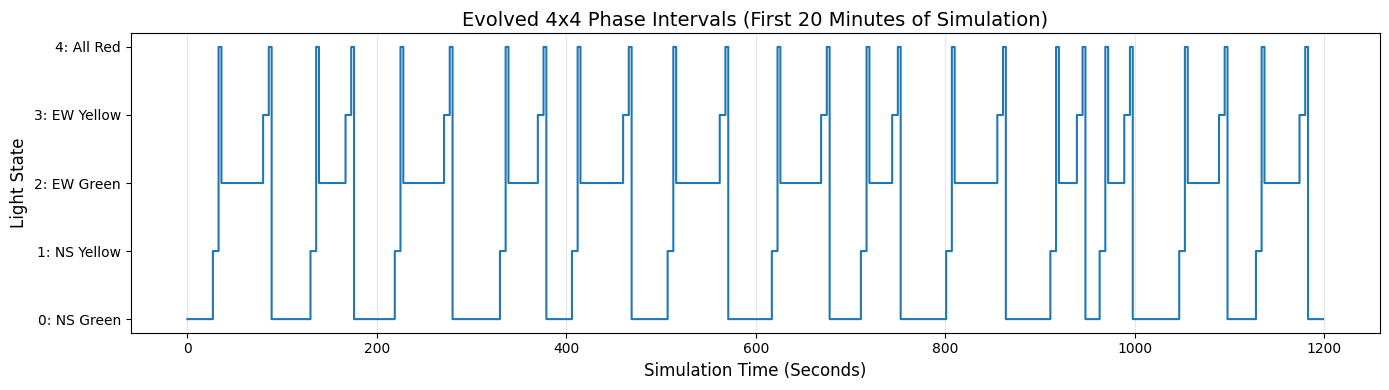

In [14]:
# Load the trained model
with open('best_timing.pkl', 'rb') as f: 
    best_blocks = pickle.load(f)

genes = flatten_genes(best_blocks)

# Generate the static plot
plt.figure(figsize=(14, 4))
plt.plot(genes[:1200], color='#1f77b4', drawstyle='steps-post', linewidth=1.5)

plt.title("Evolved 4x4 Phase Intervals (First 20 Minutes of Simulation)", fontsize=14)
plt.xlabel("Simulation Time (Seconds)", fontsize=12)
plt.ylabel("Light State", fontsize=12)

# Custom y-axis labels for clarity in the presentation
plt.yticks([0, 1, 2, 3, 4], [
    '0: NS Green', 
    '1: NS Yellow', 
    '2: EW Green', 
    '3: EW Yellow', 
    '4: All Red'
])

plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Simulation Replay & Throughput Analysis
This cell runs the optimal timing sequence through a visual Pygame simulation. While it renders the traffic, it simultaneously records the "Active Vehicle Density" at every second. A flat or dropping density curve indicates the EA successfully managed traffic pressure, while an exponentially rising curve indicates gridlock.

In [15]:
def run_validation_replay(genes, seed=3000):
    pygame.init()
    screen = pygame.display.set_mode((800, 850))
    pygame.display.set_caption("CISC455: Final Strategy Replay")
    clock = pygame.time.Clock()
    
    random.seed(seed)
    vehicles = []
    active_vehicles = []
    density_history = []
    vid = 0
    
    for t in range(3600):
        # Handle Pygame events to prevent window unresponsiveness
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                return density_history
                
        # Continuous spawning
        if random.random() < SPAWN_RATE:
            ax, dr, ch = random.choice(['h','v']), random.choice([1,-1]), random.choice(INTERSECTIONS)
            spawn_pos = 0 if dr == 1 else ROAD_LEN
            if all(abs(v.pos - spawn_pos) > 20 for v in active_vehicles if v.axis == ax and v.channel == ch and v.direction == dr):
                new_v = Vehicle(vid, random.choice(['car','bus']), ax, dr, ch)
                vehicles.append(new_v)
                active_vehicles.append(new_v)
                vid += 1
                
        light = genes[t]
        
        # Render every frame for smooth replay
        screen.fill((230, 230, 230))
        for r in INTERSECTIONS:
            pygame.draw.rect(screen, (50, 50, 50), (0, r * 0.8 - 20, 800, 40))
            pygame.draw.rect(screen, (50, 50, 50), (r * 0.8 - 20, 0, 40, 800))
        
        c = {0: (0, 255, 0), 1: (255, 255, 0), 2: (0, 100, 0), 3: (100, 100, 0), 4: (255, 0, 0)}
        for rx in INTERSECTIONS:
            for ry in INTERSECTIONS:
                pygame.draw.circle(screen, c.get(light, (255, 0, 0)), (int(rx * 0.8), int(ry * 0.8)), 14)
                
        for v in active_vehicles:
            col = (0, 100, 255) if v.length == 1 else (255, 140, 0)
            s_pos = v.pos * 0.8
            if v.axis == 'h':
                lane_off = -15 if v.direction == 1 else 5
                pygame.draw.rect(screen, col, (s_pos, v.channel * 0.8 + lane_off, v.length * 8, 12))
            else:
                lane_off = -15 if v.direction == 1 else 5
                pygame.draw.rect(screen, col, (v.channel * 0.8 + lane_off, s_pos, 12, v.length * 8))

        pygame.draw.rect(screen, (255, 255, 255), (0, 800, 800, 50))
        font = pygame.font.SysFont("Consolas", 16)
        screen.blit(font.render(f"VALIDATION REPLAY | SEED: {seed}", True, (0, 0, 0)), (20, 810))
        screen.blit(font.render(f"SIM TIME: {t}s / 3600s", True, (0, 0, 0)), (280, 810))
        screen.blit(font.render(f"ACTIVE: {len(active_vehicles)}", True, (0, 0, 0)), (580, 810))
        pygame.display.flip()
        clock.tick(120)

        # Physics Step
        next_active = []
        for v in active_vehicles:
            dist = float('inf')
            valid_stops = []
            for stop in INTERSECTIONS:
                stop_line = stop - 12 if v.direction == 1 else stop + 12
                if (v.direction == 1 and v.pos < stop_line) or (v.direction == -1 and v.pos > stop_line):
                    valid_stops.append(stop_line)
            
            if valid_stops:
                closest_stop = min(valid_stops, key=lambda x: abs(x - v.pos))
                green = (light == 0 or light == 1) if v.axis == 'v' else (light == 2 or light == 3)
                if not green:
                    dist = min(dist, abs(closest_stop - v.pos))
            
            for other in active_vehicles:
                if other.id != v.id and other.axis == v.axis and other.channel == v.channel and other.direction == v.direction:
                    if (v.direction == 1 and other.pos > v.pos) or (v.direction == -1 and other.pos < v.pos):
                        dist = min(dist, abs(other.pos - v.pos) - other.length)
            
            v.step(dist)
            if not v.finished: next_active.append(v)
            
        active_vehicles = next_active
        
        # Log density for data analysis
        density_history.append(len(active_vehicles))

    pygame.quit()
    return density_history

print("Running Visual Replay... (A Pygame window should open)")
density_data = run_validation_replay(genes, seed=3000)
print("Replay Complete.")

Running Visual Replay... (A Pygame window should open)
Replay Complete.


## 4. Density vs. Time Analysis
By plotting the number of active vehicles over the course of the simulation, we can prove the stability of the evolved timing sequence. A successful EA model will find an equilibrium state, preventing the traffic count from compounding infinitely.

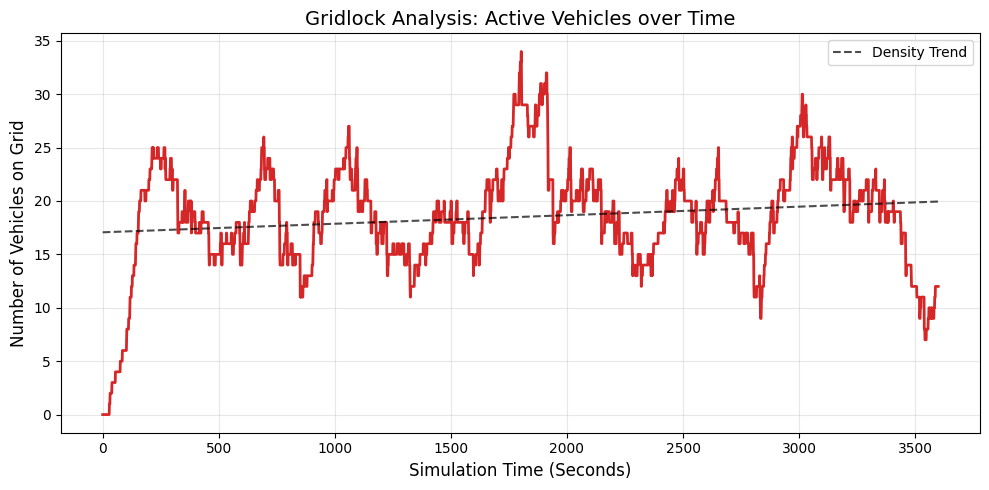

In [16]:
if density_data:
    plt.figure(figsize=(10, 5))
    plt.plot(density_data, color='#d62728', linewidth=2)
    
    plt.title("Gridlock Analysis: Active Vehicles over Time", fontsize=14)
    plt.xlabel("Simulation Time (Seconds)", fontsize=12)
    plt.ylabel("Number of Vehicles on Grid", fontsize=12)
    
    # Add a trendline to evaluate stability
    z = np.polyfit(range(len(density_data)), density_data, 1)
    p = np.poly1d(z)
    plt.plot(range(len(density_data)), p(range(len(density_data))), "k--", alpha=0.7, label="Density Trend")
    
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()